# EasyVitessce Example: SpatialData-Plot with MERFISH dataset

## Downloading and importing necessary packages

By default, interactive plots are enabled upon importing easy_vitessce. This notebook aims to demonstrate the transition between static and interactive plots, so the interactive plots are initially turned off.

In [ ]:
!pip install easy_vitessce
!pip install spatialdata
!pip install spatialdata_plot

In [1]:
import easy_vitessce as ev 
import spatialdata as sd
import spatialdata_plot
from os.path import join 

/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it 

In [2]:
# Disable interactive plots
ev.configure_plots(disable_plots=["spatialdata-plot"])

Deactivated Vitessce spatialdata-plot


## Download the data

In [3]:
import os
from os.path import join, isfile, isdir
from urllib.request import urlretrieve
import zipfile

In [4]:
data_dir = "data"
zip_path = join(data_dir, "merfish.spatialdata.zarr.zip")
sdata_path = join(data_dir, "merfish.spatialdata.zarr")

In [8]:
if not isdir(sdata_path):
    if not isfile(zip_path):
        os.makedirs(data_dir, exist_ok=True)
        urlretrieve('https://mghp.osn.xsede.org/bir190004-bucket01/BiocSpatialData/merfish.zarr.zip', zip_path)
    with zipfile.ZipFile(zip_path,"r") as zip_ref:
        zip_ref.extractall(data_dir)
        os.rename(join(data_dir, "merfish.zarr"), sdata_path)

## Read the data

In [9]:
sdata = sd.read_zarr(sdata_path)
sdata

/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


SpatialData object, with associated Zarr store: /Users/ericmoerth/ws/easy_vitessce/docs/notebooks/data/merfish.spatialdata.zarr
├── Images
│     └── 'rasterized': DataArray[cyx] (1, 522, 575)
├── Points
│     └── 'single_molecule': DataFrame with shape: (<Delayed>, 3) (2D points)
├── Shapes
│     ├── 'anatomical': GeoDataFrame shape: (6, 1) (2D shapes)
│     └── 'cells': GeoDataFrame shape: (2389, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2389, 268)
with coordinate systems:
    ▸ 'global', with elements:
        rasterized (Images), single_molecule (Points), anatomical (Shapes), cells (Shapes)

## Static plotting

/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cells` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/ericmoerth/ws/easy_vitessce/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


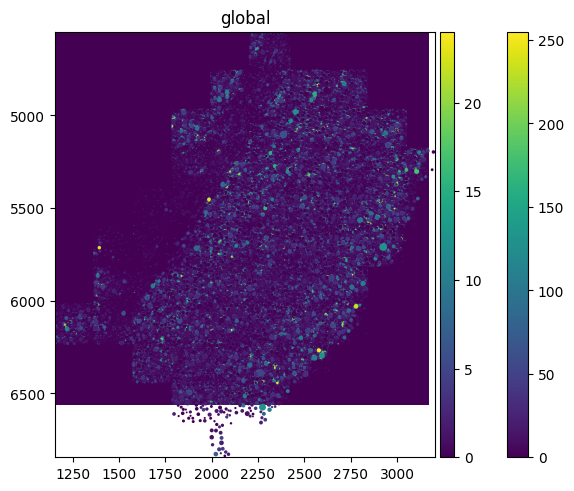

In [10]:
sdata.pl.render_images(element="rasterized").pl.render_shapes(element="cells", color="Acta2").pl.show()

In [11]:
# add another code block for the mouse liver dataset? 

## Activating interactive plots

In [17]:
# Enable interactive plots
ev.configure_plots(enable_plots=["spatialdata-plot"])

## Interactive plotting

In [18]:
del sdata._cache['pl']

AttributeError: 'SpatialData' object has no attribute '_cache'

In [19]:
sdata.pl.render_images(element="rasterized").pl.render_shapes(element="cells", color="Acta2").pl.show()

VitessceWidget(js_dev_mode=True, uid='3c80')